# Notebook 02 — Visualización de Datos
**Curso:** BD-143 Programación II — CUC 2026
**Dataset:** TMDB Movies 2020–2025

Este notebook presenta las visualizaciones generadas con la clase Visualizador,
cada gráfico cuenta una historia sobre el cine global entre 2020 y 2025.

## Configuración inicial
En esta sección se importan las librerías necesarias y se cargan
los datos usando las clases CargadorDatos y ProcesadorEda.
Se crea el objeto Visualizador con los datos limpios para
generar los gráficos.

In [31]:
import sys
import os
import matplotlib
matplotlib.rcParams['text.color'] = 'black'
matplotlib.rcParams['axes.labelcolor'] = 'black'
matplotlib.rcParams['xtick.color'] = 'black'
matplotlib.rcParams['ytick.color'] = 'black'
matplotlib.rcParams['axes.titlecolor'] = 'black'
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.spines.left'] = True
sys.path.insert(0, os.path.abspath("../src"))

from eda.cargador_datos import CargadorDatos
from eda.procesador_eda import ProcesadorEda
from visualizacion.visualizador import Visualizador

ruta = "../data/raw/tmdb_2020_to_2025.csv"
cargador = CargadorDatos(ruta)
df = cargador.cargar()

procesador = ProcesadorEda(df)
df_limpio = procesador.limpieza_datos()

viz = Visualizador(df_limpio)

Filas cargadas 9999
Valores nulos por columna:
                   cantidad  porcentaje %
adult                     0          0.00
backdrop_path          1881         18.81
genre_ids                 0          0.00
id                        0          0.00
original_language         0          0.00
original_title            0          0.00
overview                278          2.78
popularity                0          0.00
poster_path             243          2.43
release_date              0          0.00
title                     0          0.00
video                     0          0.00
vote_average              0          0.00
vote_count                0          0.00
Limpieza de datos completada
Columnas actuales: ['genre_ids', 'id', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count', 'anio_estreno']
Dataset limpio guardado en ../../data/processed/tmdb_movies_clean.csv


### Resultado de la carga
- Se cargaron 9,999 películas con 14 columnas
- Se realizó la limpieza de datos eliminando columnas innecesarias
- El dataset limpio quedó con 11 columnas listo para visualizar

## Gráfico 1 — Distribución de calificaciones
¿Cómo califican los usuarios las películas de TMDB 2020-2025?

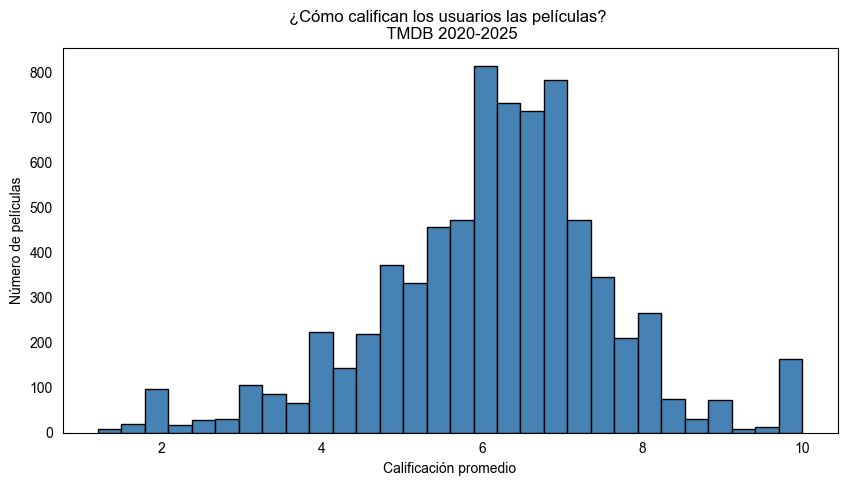

In [32]:
viz.histograma_calificaciones()

### Interpretación
- La mayoría de las películas tienen calificaciones entre 5 y 7.5 puntos
- La distribución tiene forma de campana, lo que indica que pocas películas
  tienen calificaciones extremas (muy bajas o muy altas)
- Se filtraron películas con calificación menor a 1 porque corresponden
  a estrenos futuros que aún no tienen votos reales
- La calificación más frecuente está alrededor de 6 puntos

## Gráfico 2 — Películas producidas por año
¿Cuántas películas se produjeron cada año entre 2020 y 2025?

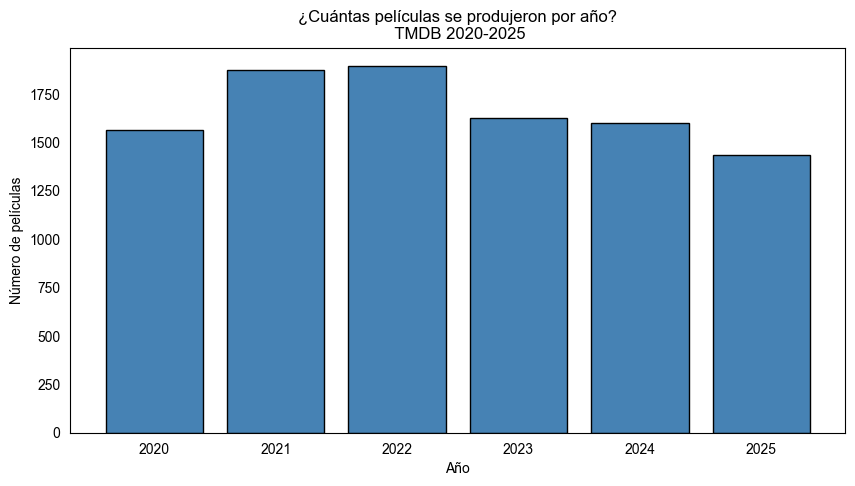

In [33]:
viz.barras_por_anio()

### Interpretación
- 2022 fue el año con más estrenos con 1,895 películas
- 2020 tuvo la menor producción posiblemente por el impacto del COVID-19
- La industria se recuperó en 2021 y alcanzó su pico en 2022
- 2025 tiene menos películas porque el año no había terminado
  al momento de extraer los datos

## Gráfico 3 — Popularidad vs Calificación
¿Las películas más populares son las mejor calificadas?

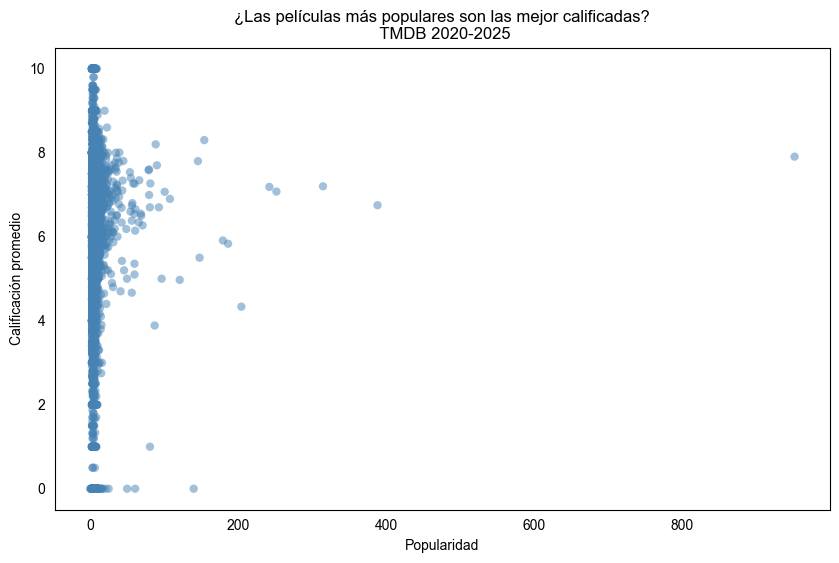

In [34]:
viz.scatter_popularidad_rating()

### Interpretación
- No existe una relación clara entre popularidad y calificación
- La mayoría de las películas tienen popularidad baja pero calificaciones variadas
- El punto más extremo a la derecha es Frankenstein con popularidad de 951
- Ser popular no garantiza tener buena calificación

## Gráfico 4 — Matriz de correlación
¿Qué variables están más relacionadas entre sí?

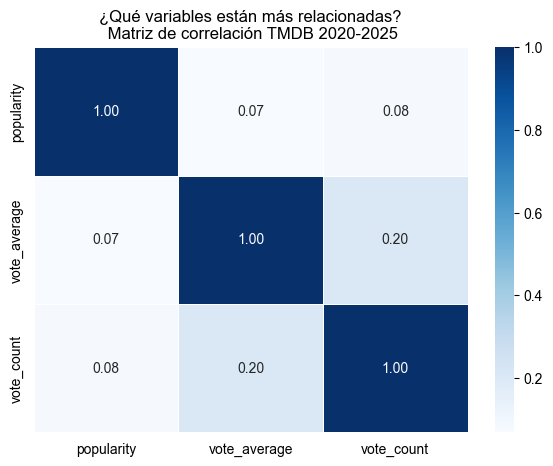

In [35]:
viz.heatmap_correlacion()

### Interpretación
- La diagonal siempre es 1.00 porque cada variable se correlaciona consigo misma
- vote_average y vote_count tienen la correlación más alta con 0.20,
  las películas mejor calificadas tienden a tener más votos
- popularity tiene correlación muy baja con las demás variables (0.07 y 0.08)
- En general las variables son independientes entre sí

## Gráfico 5 — Top 10 géneros más frecuentes
¿Qué tipo de películas domina la producción cinematográfica global?

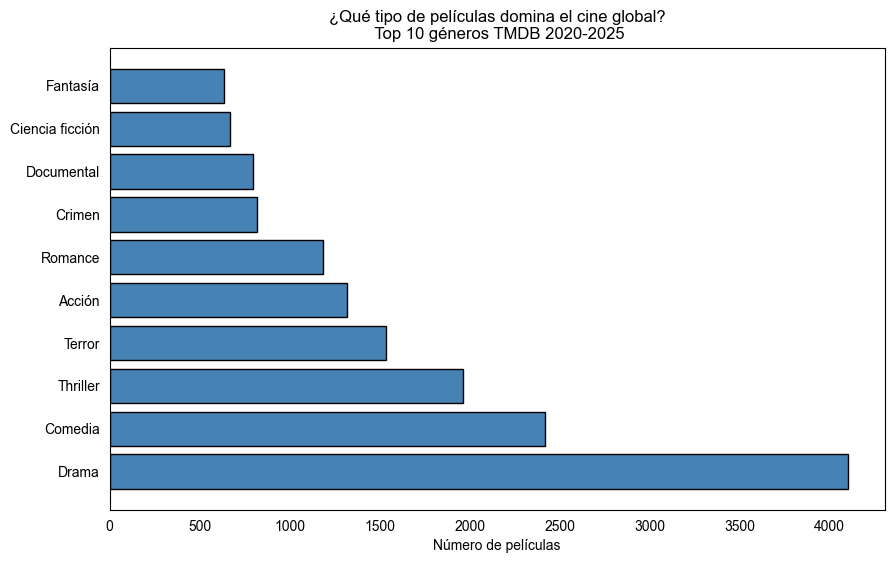

In [36]:
viz.barras_top_generos()

### Interpretación
- Drama domina con más de 4,000 películas, casi el doble que Comedia
- Thriller y Terror ocupan el tercer y cuarto lugar respectivamente
- Fantasía y Ciencia ficción son los menos frecuentes del top 10
- Una película puede pertenecer a varios géneros a la vez

## Gráfico 6 — Top 10 películas más populares
¿Cuáles son las películas que más atención generaron en TMDB?

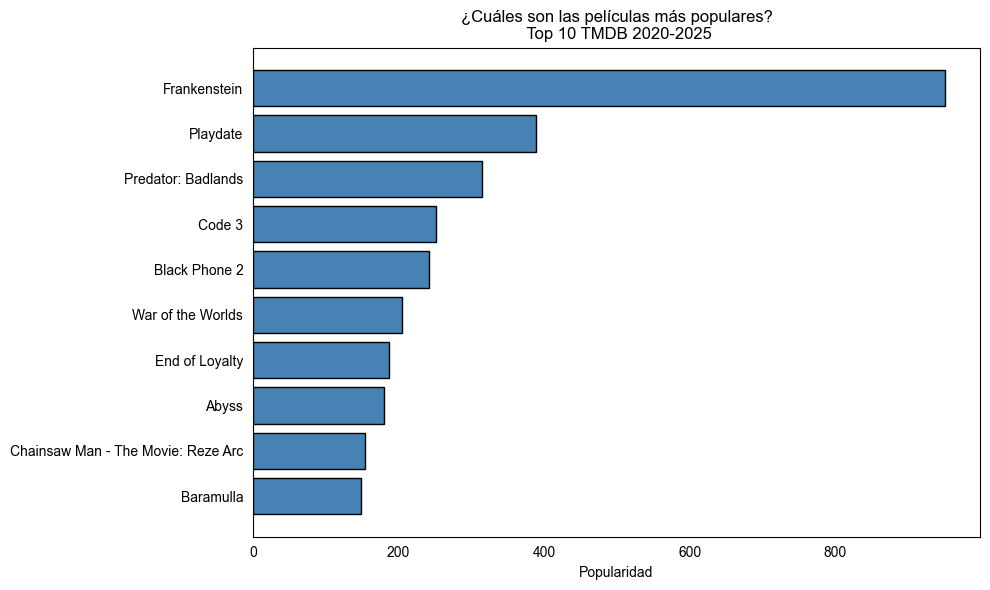

In [37]:
viz.barras_top_peliculas_populares()

## Interpretación
- Frankenstein lidera con 951 puntos, casi el triple que Playdate en segundo lugar
- La mayoría son secuelas o franquicias conocidas como Predator y Black Phone
- La popularidad en TMDB refleja actividad reciente como visitas y listas de usuarios
- Hay una brecha enorme entre Frankenstein y el resto, confirmando que es un outlier

## Gráfico 7 — Promedio de calificación por género
¿Qué géneros producen las películas mejor calificadas?

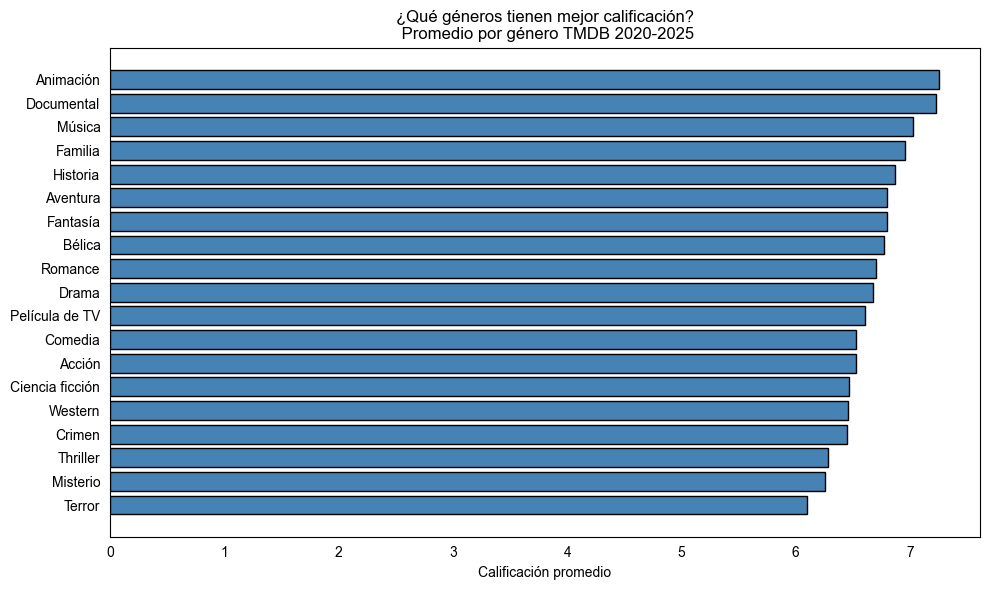

In [38]:
viz.barras_promedio_por_genero()

## Interpretación
- Animación y Documental son los géneros mejor calificados con 7.25 y 7.23
- Terror es el género peor calificado con 6.10 a pesar de ser muy producido
- La diferencia entre el mejor y peor género es de solo 1.15 puntos
- Se filtraron películas con menos de 50 votos para mayor confiabilidad

## Gráfico 8 — Top 10 idiomas más frecuentes
¿En qué idiomas se produce más cine a nivel mundial?

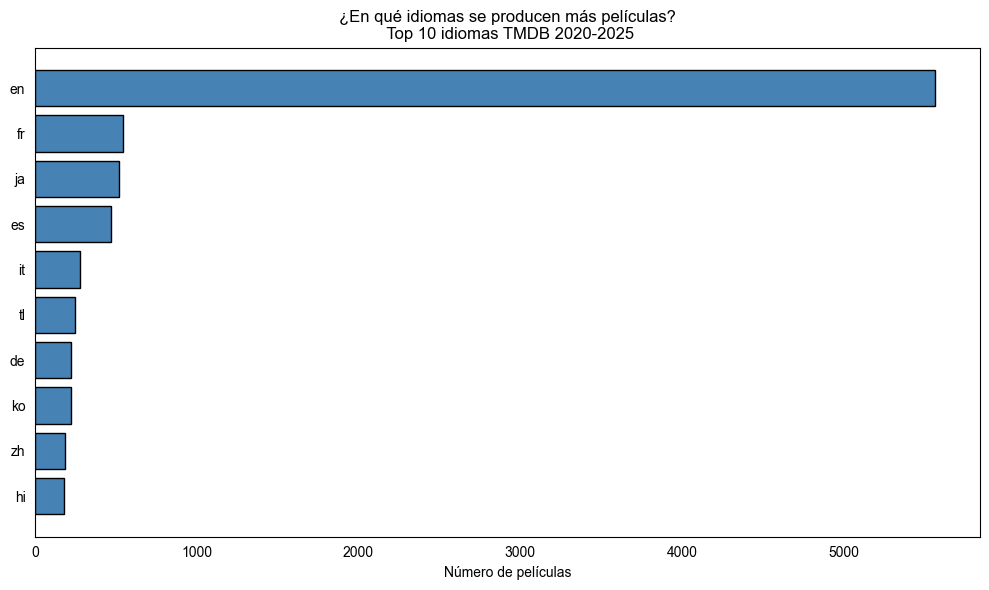

In [39]:
viz.barras_top_idiomas()

## Interpretación
- El inglés domina con 5,566 películas, representando el 55% del dataset
- Francia y Japón ocupan el segundo y tercer lugar con fuerte industria cinematográfica
- El español aparece en cuarto lugar con 470 películas
- Hay 81 idiomas distintos en total pero los 10 primeros concentran la mayoría

## Conclusiones generales
- El cine global está dominado por el Drama y la Comedia
- La popularidad y la calificación son métricas independientes
- 2022 fue el año más productivo del período 2020-2025
- La mayoría de películas tienen calificaciones entre 5 y 7.5 puntos